# TEAM 28: physical CLN and same-mesh FEM levitation force

This executed notebook reads newly recomputed evidence from the public reproduction script. It does not contain imported force reference data. The reference at each height is a separate full finite-element solve on the **same mesh**. The external measured reference is only the stationary height **11.3 mm** in the [official TEAM 28 specification](https://www.compumag.org/jsite/images/stories/TEAM/problem28.pdf).

Scope: **Model A**, axisymmetric aluminum disk, prescribed sinusoidal winding currents at 50 Hz, fixed-height peak phasors. Model B, moving/transient electromechanics and winding resistance are outside this demonstration. The disk mass is 0.107 kg, conductivity $3.4\times10^7$ S/m and permeability $\mu_0$. The two winding excitations are $960I$ and $-576I$, with $I=20$ A peak.

The tests retain both requested gates: reduction force error below **1 mN at all 25 heights**, and the interpolated static equilibrium within **0.6 mm of 11.3 mm**. These are different comparisons.

Height is the distance from the upper edge of the winding current area to the lower edge of the disk, following the specification.

Reference: H. Karl, J. Fetzer, S. Kurz, G. Lehner and W. M. Rucker, *Description of TEAM Workshop Problem 28: An Electrodynamic Levitation Device* (official specification linked above).

## Regular axisymmetric fields and the physical source

Use $w=A_\theta/r$, finite on the axis, with zero $w$ on a finite semicircular outer-air boundary. Then
$$B_r=-r\partial_z w,\qquad B_z=2w+r\partial_r w,\qquad J_\theta=-s\sigma r w.$$
The bilinear forms use the physical volume measure $2\pi r\,dr\,dz$:
$$K(u,v)=2\pi\int\nu r\{r^2\partial_z u\partial_z v+(2u+r\partial_r u)(2v+r\partial_r v)\},$$
$$M(u,v)=2\pi\int\sigma r^3uv,\qquad f(v)=2\pi\int J_{\mathrm{source},1A}r^2v.$$

Solve $(K+sM)w=fI$. The source is the actual winding excitation per unit series current. The same source defines the initial CLN field. No arbitrary snapshot or Arnoldi basis is relabelled as a physical CLN.

## Energy-normalized Type1 recursion

For $a_0=K^{-1}f$ and $e_{-1}=0$:
$$L_j=a_j^TK a_j,\quad e_j=e_{j-1}+a_j/L_j,\quad R_j=(e_j^TM e_j)^{-1},$$
$$a_{j+1}=a_j-R_jK^{-1}M e_j.$$

Six magnetic states give twelve alternating physical elements, in henry and ohm, at $s_0=0$. For the prescribed coil current, the induced port impedance vanishes at $s=0$, so the ladder starts with the magnetic shunt $sL_0$: Type1. Winding resistance is excluded and would be a separate series element. The truncated ladder ends at the sixth series resistor. This is not a shifted/Type2 or general 3D demonstration.

The [Wolfram derivation](../mathematica/derive_energy_recursion.wls) proves exact equality for an exhausted $n=N=2$ SPD example, with $K=I$ and an axial source without loss of generality by congruence and rotation. Two additional exact rational truncated examples use non-identity $K$ and semidefinite $M$; they verify ladder/Galerkin equality and moment contact for those instances, not a general theorem. The FEM experiment checks each element against a volume energy/loss integral and the full ladder against the energy-projected field response at five frequencies. [Field-recursion implementation notes](CLN_FIELD_RECURSION.md) explain normalization, mutable field snapshots and diagnostics.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path('data/team28_cln.json').exists() else Path.cwd()
sys.path.insert(0, str(ROOT/'validation'))
from validate_team28 import main
main()
d = json.loads((ROOT/'docs/data/team28_cln.json').read_text())
proof = json.loads((ROOT/'docs/data/energy_recursion.json').read_text())
print('Wolfram checks:', proof['checks'])
print('Runtime:', d['runtime'])
print('Source hashes:', d['source_sha256_lf'])
for case in proof["truncated_instances"]:
    print("Exact rational case:", case["full_dimension"], "dimensions,",case["states"], "states; M diagonal",case["M_diagonal"],"first error power",case["first_error_power"],case["checks"])

PASS TEAM 28: 25 forces, 1 mN / 0.6 mm gates, physical elements, power, settings probes and source hashes
Wolfram checks: {'ladder_equals_field': True, 'magnetic_energy_orthogonality': True, 'electric_loss_orthogonality': True, 'positive_elements': True, 'expected_elements': True, 'termination': True, 'peak_phasor_force_average': True}
Runtime: {'python': '3.12.10', 'ngsolve': '6.2.2607', 'netgen': '6.2.2607'}
Source hashes: {'validation/team28_cln.py': 'b220e2d711637fea46772f5d27983e34a03aaeaf8ad01ca13dec73e4b09e6512', 'validation/surface_hybrid/ladder_eval.py': 'fc431aba383eb33bfb5fa9e6c5c7632afc0ad74dcc1d3919b9cc0503fb34eaa6'}
Exact rational case: 5 dimensions, 2 states; M diagonal [1, 2, 3, 0, 0] first error power 5 {'ladder_equals_galerkin': True, 'positive_elements': True, 'magnetic_orthogonality': True, 'electric_orthogonality': True, 'nonzero_remaining_field': True, 'moment_contact': True}
Exact rational case: 6 dimensions, 3 states; M diagonal [1, 2, 3, 4, 0, 0] first error po

## Force requires reconstructed fields and a conjugate

Since $\mathbf e_\theta\times\mathbf e_r=-\mathbf e_z$, the upward time-average force for **peak** phasors is
$$F_z=-\tfrac12\operatorname{Re}\int_{\mathrm{disk}}J_\theta\overline{B_r}\,2\pi r\,dr\,dz.$$
A product without conjugation is not the phasor time average. Both full and CLN reconstructed fields use this expression. Electrical loss is checked independently against $\tfrac12I_{\rm peak}^2\operatorname{Re}Z$, where $Z=s f^T(K+sM)^{-1}f$. Terminal agreement alone cannot guarantee force accuracy.

height_mm  full_N        CLN_N         error_mN
  3.8       3.304742476   3.304742731  0.000254554
  4.8       2.849828532   2.849828756  0.000224795
  5.8       2.451877808   2.451878007  0.000198864
  6.8       2.104140106   2.104140282  0.000175751
  7.8       1.800786528   1.800786683  0.000155437
  8.8       1.536313915   1.536314052  0.000136912
  9.8       1.306242240   1.306242361  0.000121014
 10.8       1.106238969   1.106239076  0.000106684
 11.8       0.932659605   0.932659699  9.40184e-05
 12.8       0.782388013   0.782388095  8.24478e-05
 13.8       0.652400609   0.652400682  7.23733e-05
 14.8       0.540337954   0.540338018  6.33559e-05
 15.8       0.443859647   0.443859702  5.53666e-05
 16.8       0.361091066   0.361091115  4.82758e-05
 17.8       0.290332688   0.290332730  4.20162e-05
 18.8       0.229924087   0.229924123  3.64531e-05
 19.8       0.178709399   0.178709431  3.15912e-05
 20.8       0.135296487   0.135296514  2.72001e-05
 21.8       0.098817203   0.098817

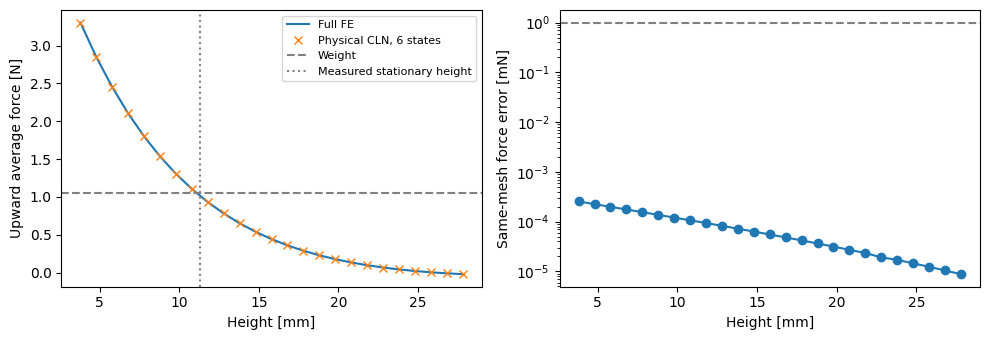

In [2]:
rows = d['heights']
h = np.array([r['height_mm'] for r in rows])
full = np.array([r['full_upward_force_N'] for r in rows])
cln = np.array([r['cln_upward_force_N'] for r in rows])
err = np.abs(full-cln)
print('height_mm  full_N        CLN_N         error_mN')
for a,b,c,e in zip(h,full,cln,err):
    print(f'{a:5.1f}      {b:12.9f}  {c:12.9f}  {1e3*e:.6g}')
print('Maximum force error [mN]:',1e3*max(err))
print('Full / CLN 1 mm-grid interpolants [mm]:',f"{d['full_equilibrium_height_mm']:.2f}",f"{d['cln_equilibrium_height_mm']:.2f}")
print('Interpolant gaps to 11.3 mm [mm]:',f"{d['full_equilibrium_reference_error_mm']:.3f}",f"{d['cln_equilibrium_reference_error_mm']:.3f}")
fig, ax = plt.subplots(1,2,figsize=(10,3.5))
ax[0].plot(h,full,label='Full FE'); ax[0].plot(h,cln,'x',label='Physical CLN, 6 states')
ax[0].axhline(d['disk_mass_kg']*d['gravity_m_s2'],color='gray',linestyle='--',label='Weight')
ax[0].axvline(11.3,color='gray',linestyle=':',label='Measured stationary height')
ax[0].set(xlabel='Height [mm]',ylabel='Upward average force [N]'); ax[0].legend(fontsize=8)
ax[1].semilogy(h,1e3*err,'o-'); ax[1].axhline(1,color='gray',linestyle='--')
ax[1].set(xlabel='Height [mm]',ylabel='Same-mesh force error [mN]')
fig.tight_layout(); plt.show()

In [3]:
example = rows[8]
print('Physical elements at',example['height_mm'],'mm')
print('stage   L [H]           R [ohm]')
for j,(l,r) in enumerate(zip(example['L_henry'],example['R_ohm'])):
    print(f'{j:2d}      {l:.10g}     {r:.10g}')
for key in ['full_relative_residual','circuit_field_relative_defect',
            'magnetic_energy_orthogonality','electric_loss_orthogonality',
            'element_volume_integral_defect','full_power_relative_defect']:
    print(key, max(r[key] for r in rows))

Physical elements at 11.8 mm
stage   L [H]           R [ohm]
 0      0.07383189075     7969.363358
 1      6.964388049     29755.84228
 2      22.91553474     199323.4427
 3      55.21099741     515862.2154
 4      78.64439181     900248.5448
 5      114.2580948     1896598.72
full_relative_residual 8.063205846251973e-14
circuit_field_relative_defect 3.3310886582811195e-15
magnetic_energy_orthogonality 2.4018562612694177e-12
electric_loss_orthogonality 9.485452967848271e-12
element_volume_integral_defect 2.2870594307278225e-14
full_power_relative_defect 1.3766765505351941e-14


## Separate the reduction gate from full-model uncertainty

The stable equilibrium is the downward-slope force/weight crossing, linearly interpolated between adjacent heights of the specified 1 mm grid. It is a static approximation, not a time-domain motion simulation. Finite air, mesh and interpolation errors remain. The default air radius is 0.60 m, second-order elements, global maxh 6 mm, disk maxh 1.5 mm and common quadrature order 12.

Two additional settings probes use heights 10.8 and 11.8 mm, bracketing the crossing. One refines global maxh to 4 mm with disk maxh unchanged; the other increases the outer-air radius to 0.90 m. Their equilibrium estimates and individual forces are recorded below. Neither two-point probe is a certified continuum or infinite-domain result. The small force reduction error cannot remove these full-model differences.

A separate [root-refinement producer](../validation/team28_refine_equilibrium.py) evaluates fresh full/CLN forces inside the crossing bracket. This distinguishes the agreement of the two 1 mm-grid interpolants from their interpolation bias. Near the root, remeshing can cause small force fluctuations. The refined bracket is a local numerical check, not a continuum error bound. The settings probes below remain 1 mm-grid interpolants; very small differences between them should not be read as converged mesh accuracy.

In [4]:
print('Default 1 mm-grid interpolant [mm]:',f"{d['full_equilibrium_height_mm']:.2f}")
for p in d['settings_probes']:
    print(p['label'],'maxh [m]',p['mesh_maxh_m'],'air radius [m]',p['air_radius_m'])
    print('Two-point interpolant [mm]:',f"{p['full_equilibrium_height_mm']:.2f}")
    for r in p['heights']:
        print('height',r['height_mm'],'force [N]',r['full_upward_force_N'],
              'elements',r['ne'],'free DOFs',r['free_dofs'])
refined=json.loads((ROOT/'docs/data/team28_equilibrium.json').read_text())
print('Refined local bracket width [mm]:',f"{refined['bracket_width_mm']:.4g}")
for kind in ['full','cln']:
    print(kind,'refined interpolant [mm]:',f"{refined[kind+'_equilibrium_height_mm']:.2f}",
          'gap to 11.3 mm:',f"{refined[kind+'_reference_gap_mm']:.3f}",
          'shift from 1 mm grid:',f"{refined[kind+'_grid_interpolation_shift_mm']:.3f}")
print('Fresh refinement forces:')
for row in refined['fresh_heights']:
    print(f"height {row['height_mm']:.4f} mm; full balance residual "
          f"{1e3*(row['full_upward_force_N']-d['disk_mass_kg']*d['gravity_m_s2']):.4g} mN")

Default 1 mm-grid interpolant [mm]: 11.13
finer_mesh maxh [m] 0.004 air radius [m] 0.6
Two-point interpolant [mm]: 11.13
height 10.8 force [N] 1.1061751947080067 elements 79783 free DOFs 159397
height 11.8 force [N] 0.9326141043849142 elements 79041 free DOFs 157913
larger_air maxh [m] 0.006 air radius [m] 0.9
Two-point interpolant [mm]: 11.09
height 10.8 force [N] 1.099327908880521 elements 79506 free DOFs 158846
height 11.8 force [N] 0.9262265509706247 elements 80204 free DOFs 160242
Refined local bracket width [mm]: 0.0001129
full refined interpolant [mm]: 11.11 gap to 11.3 mm: 0.188 shift from 1 mm grid: -0.016
cln refined interpolant [mm]: 11.11 gap to 11.3 mm: 0.188 shift from 1 mm grid: -0.016
Fresh refinement forces:
height 11.1280 mm; full balance residual -2.768 mN
height 11.1128 mm; full balance residual -0.06598 mN
height 11.1124 mm; full balance residual -0.001203 mN
height 11.1124 mm; full balance residual -0.02058 mN
height 11.1123 mm; full balance residual 0.01192 mN


## Reproduce and validate

From the repository root:

```text
wolframscript -file mathematica/derive_energy_recursion.wls docs/data/energy_recursion.json
python validation/team28_cln.py --output docs/data/team28_cln.json
python validation/team28_refine_equilibrium.py --output docs/data/team28_equilibrium.json
python validation/validate_team28.py
```

The native producer needs NGSolve/Netgen, scipy and numpy. This notebook needs numpy, matplotlib and sympy; it reads the producer's executed evidence. CI validates stored values, strict gates, circuit reconstruction, an independent SymPy two-state identity and source identities without a native solver. Runtime and source hashes are stored in JSON. Compare regenerated JSON after LF normalization; Windows text exporters may write CRLF, while Git stores the evidence as LF. Fresh checkouts obey the repository attributes. Updating an older checkout may leave CRLF copies intact; validate a fresh checkout if protected baseline byte hashes fail. The producer marks incomplete runs explicitly and refuses a PASS when a gate fails.

The TEAM 28 numerical addition received independent Claude Opus 5.5 review in two rounds, with scientific acceptance at `345041da92087a799d47d5eed74de659b91d8c96` on 7 October 2026. The reviewer reproduced native force samples, all five local root-refinement samples and the exact Wolfram proof. This final update changes review-status text only. See [reviewed scope and limits](REVIEW_STATUS.md).